# Qwen3 4B Vast Time-Utility Results Plots

This notebook only reads saved Vast results under `results/` and replots the time-utility heatmaps.

It expects these directories to exist:

- `results/time_utility_experiment_qwen3_4b_vast_deterministic_without_thinking/`
- `results/time_utility_experiment_qwen3_4b_vast_deterministic_with_thinking/`
- `results/time_utility_experiment_qwen3_4b_vast_deterministic_steered_probe_variations_without_thinking/`
- `results/time_utility_experiment_qwen3_4b_vast_deterministic_steered_probe_variations_with_thinking/`

It combines both `without_thinking` and `with_thinking` runs in the same plots.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists() and (candidate / 'results').exists():
            return candidate
    raise RuntimeError('Could not locate the repository root from the current working directory.')


ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = ROOT / 'results'
PLOT_ROOT = RESULTS_ROOT / 'time_utility_experiment_qwen3_4b_vast_replots_both_thinking_modes'
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

MODE_ORDER = ['without_thinking', 'with_thinking']
MODE_LABELS = {
    'without_thinking': 'Without Thinking',
    'with_thinking': 'With Thinking',
}

BASELINE_SUMMARY_PATHS = {
    mode: RESULTS_ROOT / f'time_utility_experiment_qwen3_4b_vast_deterministic_{mode}' / f'mmraz_time_utility_qwen3_4b_vast_{mode}_summary.csv'
    for mode in MODE_ORDER
}
STEERED_SUMMARY_PATHS = {
    mode: RESULTS_ROOT / f'time_utility_experiment_qwen3_4b_vast_deterministic_steered_probe_variations_{mode}' / f'mmraz_time_utility_qwen3_4b_vast_{mode}_steered_probe_variations_summary.csv'
    for mode in MODE_ORDER
}

for path in [*BASELINE_SUMMARY_PATHS.values(), *STEERED_SUMMARY_PATHS.values()]:
    if not path.exists():
        raise FileNotFoundError(f'Missing expected summary file: {path}')

print('Repo root   :', ROOT)
print('Results root:', RESULTS_ROOT)
print('Plot root   :', PLOT_ROOT)


Repo root   : /Users/michalmraz/code/spar-ai/temporal-awareness
Results root: /Users/michalmraz/code/spar-ai/temporal-awareness/results
Plot root   : /Users/michalmraz/code/spar-ai/temporal-awareness/results/time_utility_experiment_qwen3_4b_vast_replots_both_thinking_modes


In [16]:
T_DELAY_ORDER = ['tomorrow', 'week', 'month', 'year', '2 years', '3 years', '5 years', '10 years']
Y_LATER_ORDER = [100, 101, 110, 150, 200, 500, 1000, 10000]
CONDITION_ORDER = [
    'steer_immediate_minus64',
    'steer_immediate_minus32',
    'steer_immediate_minus16',
    'baseline',
    'steer_long_term_plus16',
    'steer_long_term_plus32',
    'steer_long_term_plus64',
]
CONDITION_LABELS = {
    'baseline': 'baseline',
    'steer_long_term_plus16': '+16 long-term',
    'steer_immediate_minus16': '-16 immediate',
    'steer_long_term_plus32': '+32 long-term',
    'steer_immediate_minus32': '-32 immediate',
    'steer_long_term_plus64': '+64 long-term',
    'steer_immediate_minus64': '-64 immediate',
}


def to_matrix(df: pd.DataFrame, value_col: str) -> np.ndarray:
    pivot = df.pivot(index='y_later', columns='t_delay', values=value_col)
    pivot = pivot.reindex(index=Y_LATER_ORDER, columns=T_DELAY_ORDER)
    return pivot.to_numpy(dtype=float)


def empty_matrix() -> np.ndarray:
    return np.full((len(Y_LATER_ORDER), len(T_DELAY_ORDER)), np.nan, dtype=float)


def draw_heatmap(ax, matrix, title, vmin=0.0, vmax=1.0, cmap='viridis', fmt='{:.2f}'):
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='#f2f2f2')
    im = ax.imshow(matrix, aspect='auto', origin='upper', vmin=vmin, vmax=vmax, cmap=cmap_obj)
    ax.set_xticks(range(len(T_DELAY_ORDER)))
    ax.set_xticklabels(T_DELAY_ORDER, rotation=45, ha='right')
    ax.set_yticks(range(len(Y_LATER_ORDER)))
    ax.set_yticklabels(Y_LATER_ORDER)
    ax.set_xlabel('Delay')
    ax.set_ylabel('y later')
    ax.set_title(title)
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            value = matrix[row_idx, col_idx]
            if np.isnan(value):
                continue
            text_color = 'white' if value >= 0.6 else 'black'
            ax.text(col_idx, row_idx, fmt.format(value), ha='center', va='center', color=text_color, fontsize=8)
    return im


In [17]:
summary_parts = []
source_rows = []

for mode in MODE_ORDER:
    baseline_df = pd.read_csv(BASELINE_SUMMARY_PATHS[mode]).assign(condition='baseline', thinking_mode=mode)
    steered_df = pd.read_csv(STEERED_SUMMARY_PATHS[mode]).assign(thinking_mode=mode)
    summary_parts.extend([baseline_df, steered_df])
    source_rows.extend([
        {'thinking_mode': mode, 'kind': 'baseline', 'path': str(BASELINE_SUMMARY_PATHS[mode])},
        {'thinking_mode': mode, 'kind': 'steered', 'path': str(STEERED_SUMMARY_PATHS[mode])},
    ])

summary_df = pd.concat(summary_parts, ignore_index=True)
summary_df['y_later'] = summary_df['y_later'].astype(int)
for col in ['n_total', 'n_choose_x', 'n_choose_y', 'n_unparsed', 'n_parsed']:
    summary_df[col] = summary_df[col].astype(int)
for col in ['prop_choose_x_parsed', 'prop_choose_y_parsed', 'unparsed_rate']:
    summary_df[col] = summary_df[col].astype(float)

source_index_df = pd.DataFrame(source_rows)

display(source_index_df)
display(summary_df[['thinking_mode', 'condition', 'y_later', 't_delay', 'prop_choose_x_parsed', 'unparsed_rate']].head(20))
print('Thinking modes:', MODE_ORDER)
print('Conditions    :', CONDITION_ORDER)


,thinking_mode,kind,path
0,without_thinking,baseline,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,without_thinking,steered,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,with_thinking,baseline,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,with_thinking,steered,/Users/michalmraz/code/spar-ai/temporal-awaren...


,thinking_mode,condition,y_later,t_delay,prop_choose_x_parsed,unparsed_rate
0,without_thinking,baseline,100,10 years,1.0,0.0
1,without_thinking,baseline,100,2 years,1.0,0.0
2,without_thinking,baseline,100,3 years,1.0,0.0
3,without_thinking,baseline,100,5 years,1.0,0.0
4,without_thinking,baseline,100,month,1.0,0.0
5,without_thinking,baseline,100,tomorrow,1.0,0.0
6,without_thinking,baseline,100,week,1.0,0.0
7,without_thinking,baseline,100,year,1.0,0.0
8,without_thinking,baseline,101,10 years,1.0,0.0
9,without_thinking,baseline,101,2 years,1.0,0.0


Thinking modes: ['without_thinking', 'with_thinking']
Conditions    : ['steer_immediate_minus64', 'steer_immediate_minus32', 'steer_immediate_minus16', 'baseline', 'steer_long_term_plus16', 'steer_long_term_plus32', 'steer_long_term_plus64']


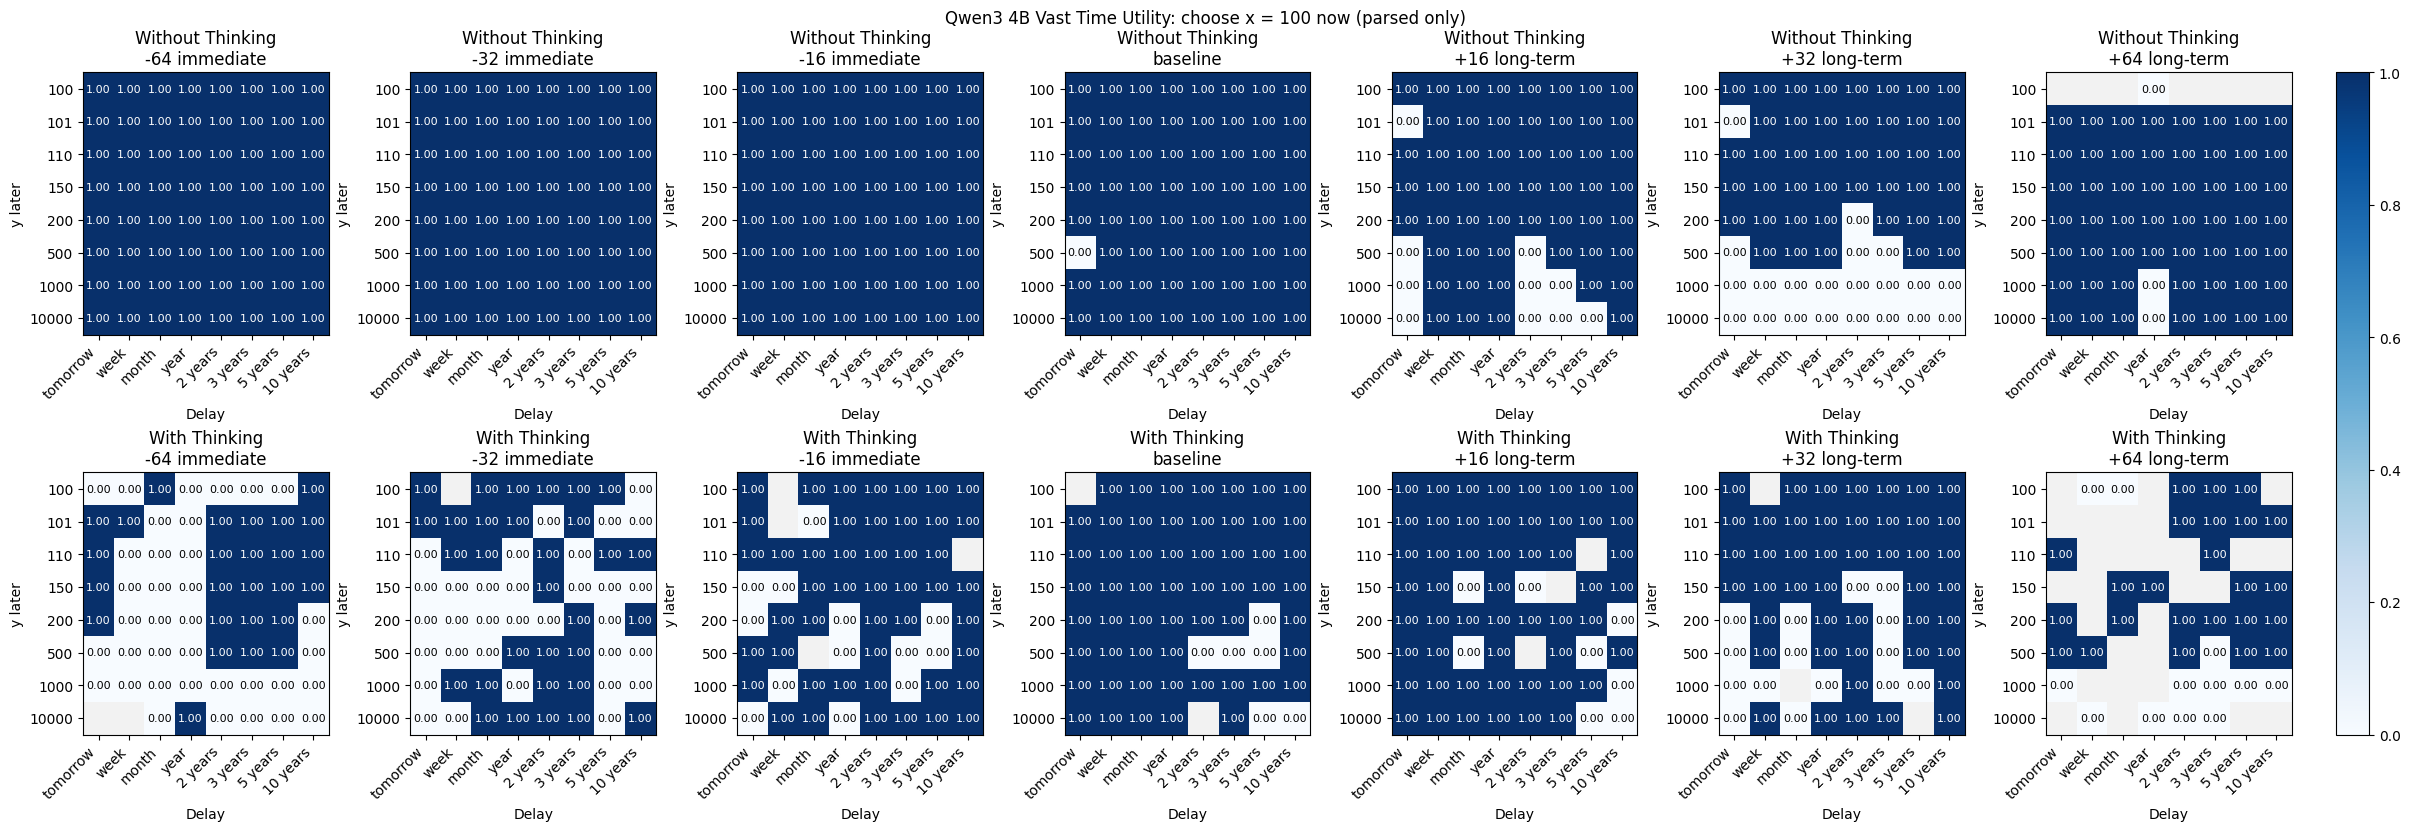

Saved choose-x heatmaps: /Users/michalmraz/code/spar-ai/temporal-awareness/results/time_utility_experiment_qwen3_4b_vast_replots_both_thinking_modes/mmraz_time_utility_qwen3_4b_vast_choose_x_now_all_conditions_both_thinking_modes.png


In [18]:
choose_x_plot_path = PLOT_ROOT / 'mmraz_time_utility_qwen3_4b_vast_choose_x_now_all_conditions_both_thinking_modes.png'

fig, axes = plt.subplots(len(MODE_ORDER), len(CONDITION_ORDER), figsize=(24, 8), constrained_layout=True)
image = None

for row_idx, mode in enumerate(MODE_ORDER):
    for col_idx, condition_name in enumerate(CONDITION_ORDER):
        ax = axes[row_idx, col_idx]
        condition_df = summary_df.loc[
            (summary_df['thinking_mode'] == mode) & (summary_df['condition'] == condition_name)
        ].copy()
        matrix = to_matrix(condition_df, 'prop_choose_x_parsed') if not condition_df.empty else empty_matrix()
        title = f"{MODE_LABELS.get(mode, mode)}\n{CONDITION_LABELS.get(condition_name, condition_name)}"
        image = draw_heatmap(ax, matrix, title, vmin=0.0, vmax=1.0, cmap='Blues')

fig.suptitle('Qwen3 4B Vast Time Utility: choose x = 100 now (parsed only)', y=1.02)
if image is not None:
    fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
fig.savefig(choose_x_plot_path, dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print('Saved choose-x heatmaps:', choose_x_plot_path)


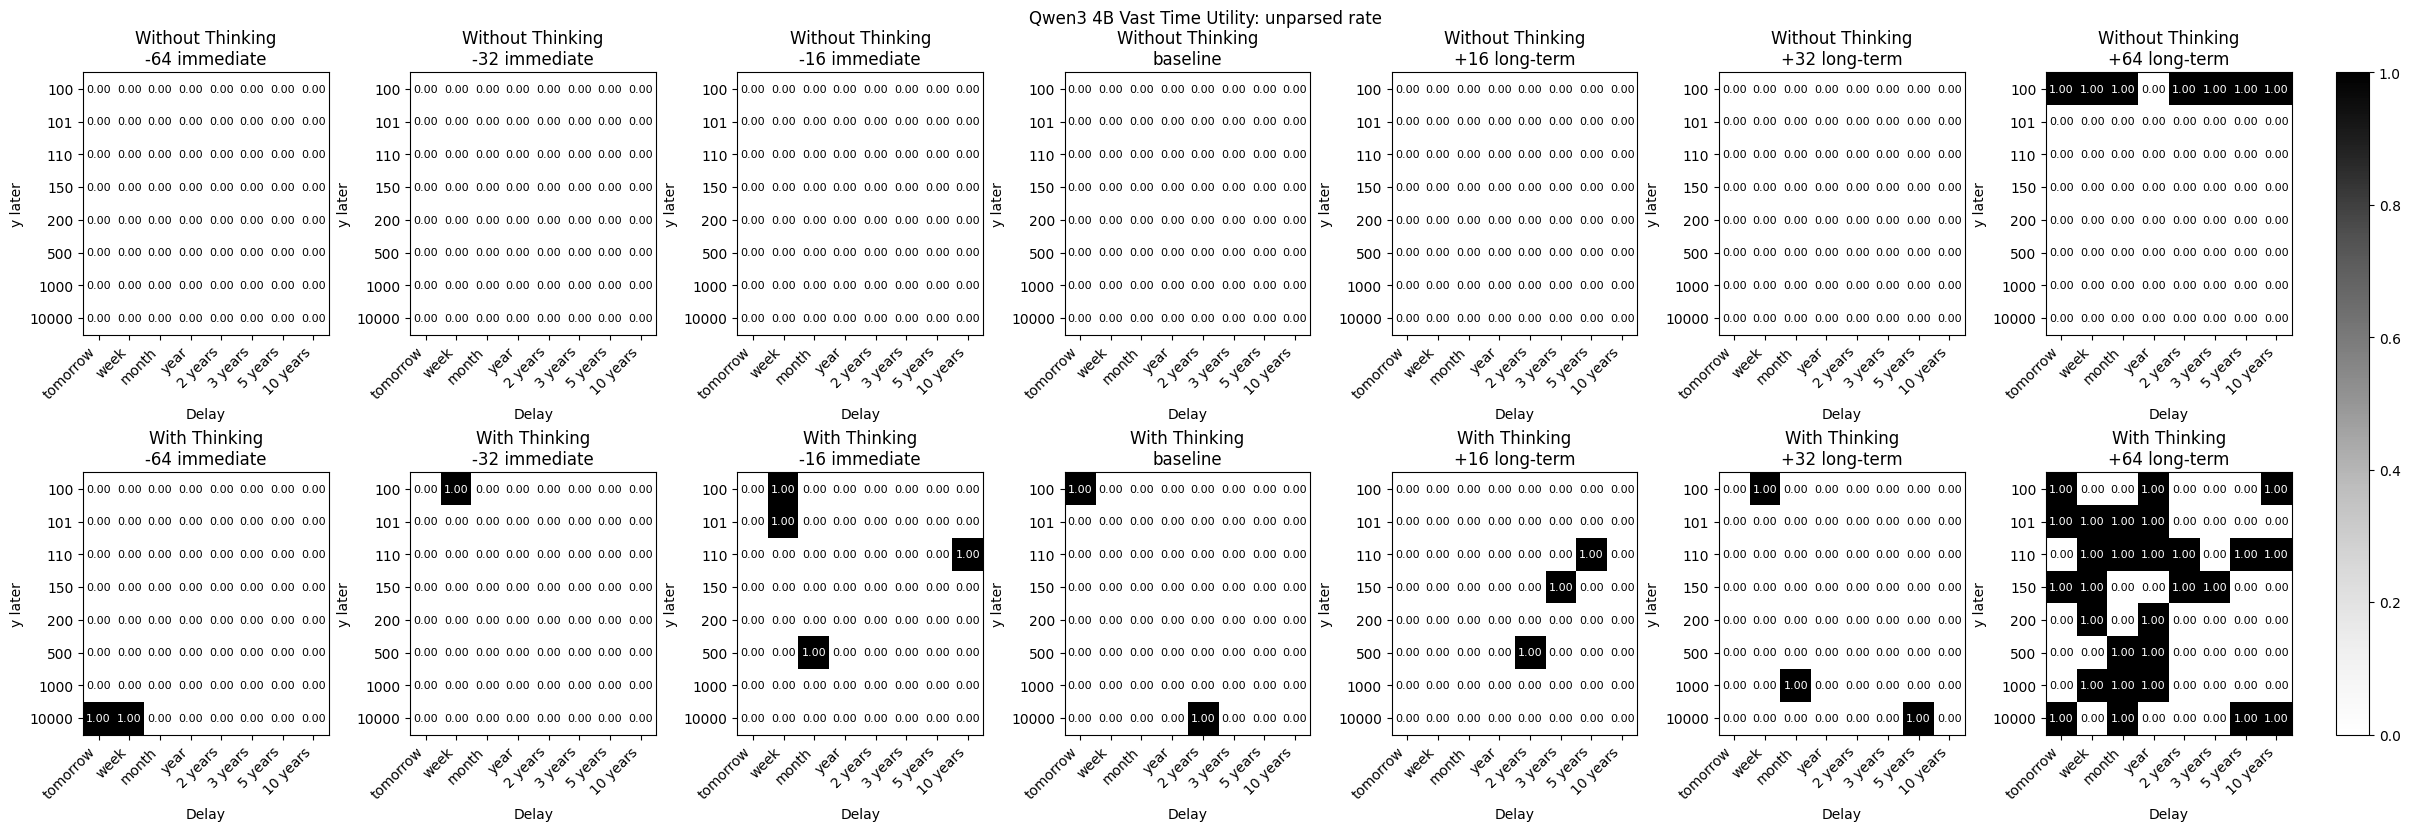

Saved unparsed heatmaps: /Users/michalmraz/code/spar-ai/temporal-awareness/results/time_utility_experiment_qwen3_4b_vast_replots_both_thinking_modes/mmraz_time_utility_qwen3_4b_vast_unparsed_rate_all_conditions_both_thinking_modes.png


In [19]:
unparsed_plot_path = PLOT_ROOT / 'mmraz_time_utility_qwen3_4b_vast_unparsed_rate_all_conditions_both_thinking_modes.png'

fig, axes = plt.subplots(len(MODE_ORDER), len(CONDITION_ORDER), figsize=(24, 8), constrained_layout=True)
image = None

for row_idx, mode in enumerate(MODE_ORDER):
    for col_idx, condition_name in enumerate(CONDITION_ORDER):
        ax = axes[row_idx, col_idx]
        condition_df = summary_df.loc[
            (summary_df['thinking_mode'] == mode) & (summary_df['condition'] == condition_name)
        ].copy()
        matrix = to_matrix(condition_df, 'unparsed_rate') if not condition_df.empty else empty_matrix()
        title = f"{MODE_LABELS.get(mode, mode)}\n{CONDITION_LABELS.get(condition_name, condition_name)}"
        image = draw_heatmap(ax, matrix, title, vmin=0.0, vmax=1.0, cmap='Greys')

fig.suptitle('Qwen3 4B Vast Time Utility: unparsed rate', y=1.02)
if image is not None:
    fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
fig.savefig(unparsed_plot_path, dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print('Saved unparsed heatmaps:', unparsed_plot_path)


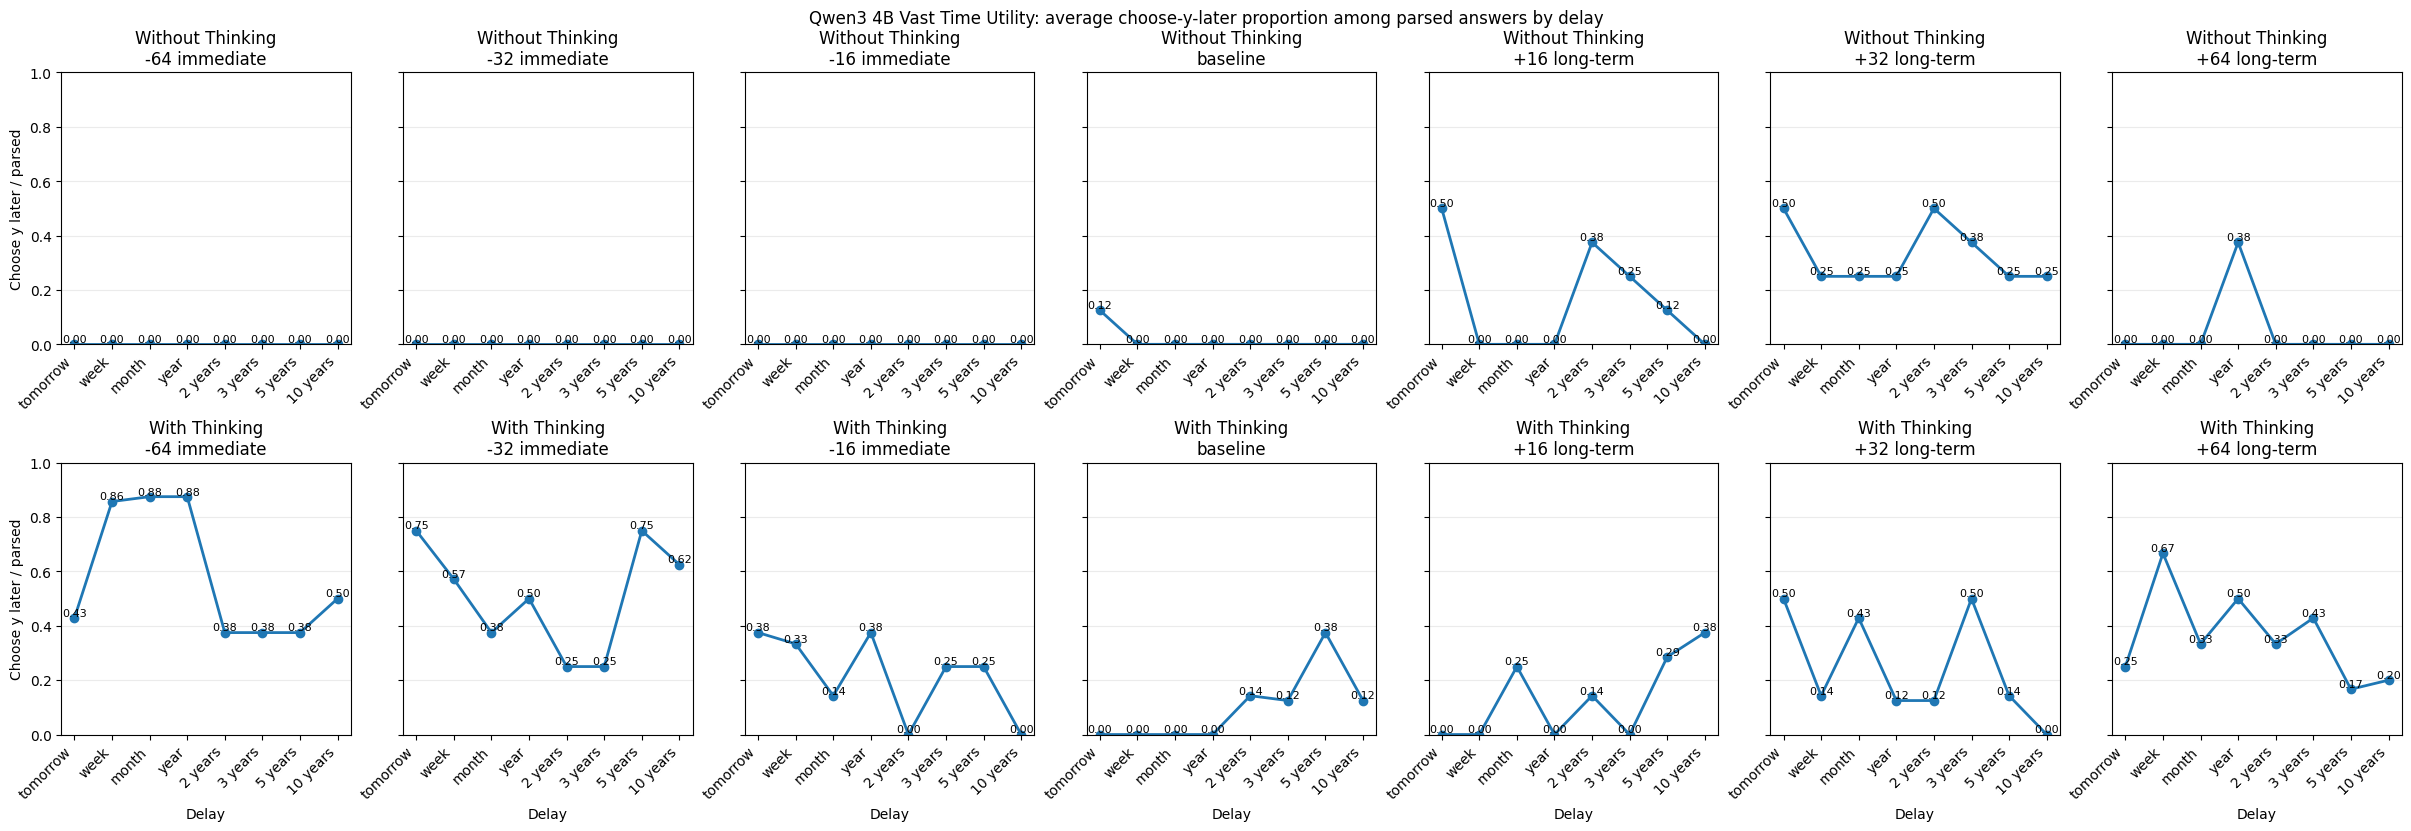

,thinking_mode,condition,t_delay,n_choose_y,n_parsed,prop_choose_y_among_parsed
0,with_thinking,baseline,tomorrow,0,7,0.000000
1,with_thinking,baseline,week,0,8,0.000000
2,with_thinking,baseline,month,0,8,0.000000
3,with_thinking,baseline,year,0,8,0.000000
4,with_thinking,baseline,2 years,1,7,0.142857
5,with_thinking,baseline,3 years,1,8,0.125000
6,with_thinking,baseline,5 years,3,8,0.375000
7,with_thinking,baseline,10 years,1,8,0.125000
8,with_thinking,steer_immediate_minus16,tomorrow,3,8,0.375000
9,with_thinking,steer_immediate_minus16,week,2,6,0.333333


Saved choose-y-by-delay plot: /Users/michalmraz/code/spar-ai/temporal-awareness/results/time_utility_experiment_qwen3_4b_vast_replots_both_thinking_modes/mmraz_time_utility_qwen3_4b_vast_choose_y_later_among_parsed_by_delay_both_thinking_modes.png


In [44]:
delay_choose_y_plot_path = PLOT_ROOT / 'mmraz_time_utility_qwen3_4b_vast_choose_y_later_among_parsed_by_delay_both_thinking_modes.png'

delay_prop_df = (
    summary_df
    .groupby(['thinking_mode', 'condition', 't_delay'], as_index=False)
    .agg(
        n_choose_y=('n_choose_y', 'sum'),
        n_parsed=('n_parsed', 'sum'),
    )
)
delay_prop_df['prop_choose_y_among_parsed'] = np.where(
    delay_prop_df['n_parsed'] > 0,
    delay_prop_df['n_choose_y'] / delay_prop_df['n_parsed'],
    np.nan,
)
delay_prop_df['t_delay'] = pd.Categorical(delay_prop_df['t_delay'], categories=T_DELAY_ORDER, ordered=True)
delay_prop_df = delay_prop_df.sort_values(['thinking_mode', 'condition', 't_delay']).reset_index(drop=True)

fig, axes = plt.subplots(len(MODE_ORDER), len(CONDITION_ORDER), figsize=(24, 8), constrained_layout=True, sharey=True)
axes = np.atleast_2d(axes)

for row_idx, mode in enumerate(MODE_ORDER):
    for col_idx, condition_name in enumerate(CONDITION_ORDER):
        ax = axes[row_idx, col_idx]
        condition_delay_df = delay_prop_df.loc[
            (delay_prop_df['thinking_mode'] == mode) & (delay_prop_df['condition'] == condition_name)
        ].copy()
        condition_delay_df = (
            condition_delay_df
            .set_index('t_delay')
            .reindex(T_DELAY_ORDER)
            .reset_index()
        )

        x_positions = np.arange(len(T_DELAY_ORDER))
        y_values = condition_delay_df['prop_choose_y_among_parsed'].to_numpy(dtype=float)

        ax.plot(x_positions, y_values, marker='o', linewidth=2)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(T_DELAY_ORDER, rotation=45, ha='right')
        ax.set_ylim(0.0, 1.0)
        ax.grid(axis='y', alpha=0.25)
        ax.set_title(f"{MODE_LABELS.get(mode, mode)}\n{CONDITION_LABELS.get(condition_name, condition_name)}")

        for x_pos, value in zip(x_positions, y_values):
            if np.isnan(value):
                continue
            ax.text(x_pos, value, f'{value:.2f}', ha='center', va='bottom', fontsize=8)

        if col_idx == 0:
            ax.set_ylabel('Choose y later / parsed')
        if row_idx == len(MODE_ORDER) - 1:
            ax.set_xlabel('Delay')

fig.suptitle('Qwen3 4B Vast Time Utility: average choose-y-later proportion among parsed answers by delay', y=1.02)
fig.savefig(delay_choose_y_plot_path, dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)

display(delay_prop_df.head(20))
print('Saved choose-y-by-delay plot:', delay_choose_y_plot_path)

In [20]:
summary_df[(summary_df.condition == 'steer_long_term_plus64') & (summary_df.thinking_mode == 'with_thinking') & (summary_df.y_later == 10000)]

,y_later,t_delay,n_total,n_choose_x,n_choose_y,n_unparsed,n_parsed,prop_choose_x_parsed,prop_choose_y_parsed,unparsed_rate,condition,thinking_mode
888,10000,10 years,1,0,0,1,0,NaN,NaN,1.0,steer_long_term_plus64,with_thinking
889,10000,2 years,1,0,1,0,1,0.0,1.0,0.0,steer_long_term_plus64,with_thinking
890,10000,3 years,1,0,1,0,1,0.0,1.0,0.0,steer_long_term_plus64,with_thinking
891,10000,5 years,1,0,0,1,0,NaN,NaN,1.0,steer_long_term_plus64,with_thinking
892,10000,month,1,0,0,1,0,NaN,NaN,1.0,steer_long_term_plus64,with_thinking
893,10000,tomorrow,1,0,0,1,0,NaN,NaN,1.0,steer_long_term_plus64,with_thinking
894,10000,week,1,0,1,0,1,0.0,1.0,0.0,steer_long_term_plus64,with_thinking
895,10000,year,1,0,1,0,1,0.0,1.0,0.0,steer_long_term_plus64,with_thinking


In [25]:
BASELINE_RAW_PATHS = {
    mode: RESULTS_ROOT / f'time_utility_experiment_qwen3_4b_vast_deterministic_{mode}' / f'mmraz_time_utility_qwen3_4b_vast_{mode}_raw.csv'
    for mode in MODE_ORDER
}
STEERED_RAW_PATHS = {
    mode: RESULTS_ROOT / f'time_utility_experiment_qwen3_4b_vast_deterministic_steered_probe_variations_{mode}' / f'mmraz_time_utility_qwen3_4b_vast_{mode}_steered_probe_variations_raw.csv'
    for mode in MODE_ORDER
}

for path in [*BASELINE_RAW_PATHS.values(), *STEERED_RAW_PATHS.values()]:
    if not path.exists():
        raise FileNotFoundError(f'Missing expected raw file: {path}')

response_parts = []
response_source_rows = []

for mode in MODE_ORDER:
    baseline_raw_df = pd.read_csv(BASELINE_RAW_PATHS[mode]).assign(
        condition='baseline',
        thinking_mode=mode,
        run_kind='baseline',
    )
    steered_raw_df = pd.read_csv(STEERED_RAW_PATHS[mode]).assign(
        thinking_mode=mode,
        run_kind='steered',
    )
    response_parts.extend([baseline_raw_df, steered_raw_df])
    response_source_rows.extend([
        {'thinking_mode': mode, 'kind': 'baseline_raw', 'path': str(BASELINE_RAW_PATHS[mode])},
        {'thinking_mode': mode, 'kind': 'steered_raw', 'path': str(STEERED_RAW_PATHS[mode])},
    ])

response_text_df = pd.concat(response_parts, ignore_index=True)
response_text_df['thinking_mode'] = pd.Categorical(response_text_df['thinking_mode'], categories=MODE_ORDER, ordered=True)
response_text_df['condition'] = pd.Categorical(response_text_df['condition'], categories=CONDITION_ORDER, ordered=True)
response_text_df['y_later'] = response_text_df['y_later'].astype(int)
response_text_df = response_text_df.sort_values(['thinking_mode', 'condition', 'y_later', 't_delay']).reset_index(drop=True)

response_source_index_df = pd.DataFrame(response_source_rows)
display(response_source_index_df)
display(response_text_df[['thinking_mode', 'condition', 'y_later', 't_delay', 'choice', 'response_for_parse', 'response']].head(10))

,thinking_mode,kind,path
0,without_thinking,baseline_raw,/Users/michalmraz/code/spar-ai/temporal-awaren...
1,without_thinking,steered_raw,/Users/michalmraz/code/spar-ai/temporal-awaren...
2,with_thinking,baseline_raw,/Users/michalmraz/code/spar-ai/temporal-awaren...
3,with_thinking,steered_raw,/Users/michalmraz/code/spar-ai/temporal-awaren...


,thinking_mode,condition,y_later,t_delay,choice,response_for_parse,response
0,without_thinking,steer_immediate_minus64,100,10 years,x_now,I prefer $100 now.,I prefer $100 now.
1,without_thinking,steer_immediate_minus64,100,2 years,x_now,I prefer $100 now.,I prefer $100 now.
2,without_thinking,steer_immediate_minus64,100,3 years,x_now,I prefer $100 now.,I prefer $100 now.
3,without_thinking,steer_immediate_minus64,100,5 years,x_now,I prefer $100 now.,I prefer $100 now.
4,without_thinking,steer_immediate_minus64,100,month,x_now,I prefer $100 now.,I prefer $100 now.
5,without_thinking,steer_immediate_minus64,100,tomorrow,x_now,I prefer $100 now.,I prefer $100 now.
6,without_thinking,steer_immediate_minus64,100,week,x_now,I prefer $100 now.,I prefer $100 now.
7,without_thinking,steer_immediate_minus64,100,year,x_now,I prefer $100 now.,I prefer $100 now.
8,without_thinking,steer_immediate_minus64,101,10 years,x_now,I prefer $100 now.,I prefer $100 now.
9,without_thinking,steer_immediate_minus64,101,2 years,x_now,I prefer $100 now.,I prefer $100 now.


In [36]:
df = response_text_df[['thinking_mode', 'condition', 'y_later', 't_delay', 'choice', 'response_for_parse', 'response']]


In [37]:
df

,thinking_mode,condition,y_later,t_delay,choice,response_for_parse,response
0,without_thinking,steer_immediate_minus64,100,10 years,x_now,I prefer $100 now.,I prefer $100 now.
1,without_thinking,steer_immediate_minus64,100,2 years,x_now,I prefer $100 now.,I prefer $100 now.
2,without_thinking,steer_immediate_minus64,100,3 years,x_now,I prefer $100 now.,I prefer $100 now.
3,without_thinking,steer_immediate_minus64,100,5 years,x_now,I prefer $100 now.,I prefer $100 now.
4,without_thinking,steer_immediate_minus64,100,month,x_now,I prefer $100 now.,I prefer $100 now.
...,...,...,...,...,...,...,...
891,with_thinking,steer_long_term_plus64,10000,5 years,unparsed,"<think>\nOkay, so the user is asking whether i...","<think>\nOkay, so the user is asking whether i..."
892,with_thinking,steer_long_term_plus64,10000,month,unparsed,"<think>\nOkay, so the user is asking which is ...","<think>\nOkay, so the user is asking which is ..."
893,with_thinking,steer_long_term_plus64,10000,tomorrow,unparsed,"<think>\nOkay, so the user is asking which is ...","<think>\nOkay, so the user is asking which is ..."
894,with_thinking,steer_long_term_plus64,10000,week,y_later,The long-term value of $10000 is better.,"<think>\nOkay, so the user is asking which is ..."


In [39]:
df = df[df.thinking_mode == 'with_thinking']

In [42]:
df[df.y_later == 101]

,thinking_mode,condition,y_later,t_delay,choice,response_for_parse,response
456,with_thinking,steer_immediate_minus64,101,10 years,x_now,"<think>\nOkay, the user is asking whether to t...","<think>\nOkay, the user is asking whether to t..."
457,with_thinking,steer_immediate_minus64,101,2 years,x_now,"<think>\nOkay, I need to figure out whether to...","<think>\nOkay, I need to figure out whether to..."
458,with_thinking,steer_immediate_minus64,101,3 years,x_now,"<think>\nOkay, I need to figure out whether to...","<think>\nOkay, I need to figure out whether to..."
459,with_thinking,steer_immediate_minus64,101,5 years,x_now,"<think>\nOkay, I need to figure out whether to...","<think>\nOkay, I need to figure out whether to..."
460,with_thinking,steer_immediate_minus64,101,month,y_later,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
461,with_thinking,steer_immediate_minus64,101,tomorrow,x_now,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
462,with_thinking,steer_immediate_minus64,101,week,x_now,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
463,with_thinking,steer_immediate_minus64,101,year,y_later,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
520,with_thinking,steer_immediate_minus32,101,10 years,y_later,"<think>\nOkay, the user is asking whether I pr...","<think>\nOkay, the user is asking whether I pr..."
521,with_thinking,steer_immediate_minus32,101,2 years,y_later,"<think>\nOkay, the user is asking whether I pr...","<think>\nOkay, the user is asking whether I pr..."


In [43]:
df[df.y_later == 1000]

,thinking_mode,condition,y_later,t_delay,choice,response_for_parse,response
496,with_thinking,steer_immediate_minus64,1000,10 years,y_later,"<think>\nOkay, the user is asking whether to t...","<think>\nOkay, the user is asking whether to t..."
497,with_thinking,steer_immediate_minus64,1000,2 years,y_later,"<think>\nOkay, the user is asking whether to t...","<think>\nOkay, the user is asking whether to t..."
498,with_thinking,steer_immediate_minus64,1000,3 years,y_later,"<think>\nOkay, the user is asking whether to t...","<think>\nOkay, the user is asking whether to t..."
499,with_thinking,steer_immediate_minus64,1000,5 years,y_later,"<think>\nOkay, the user is asking whether to t...","<think>\nOkay, the user is asking whether to t..."
500,with_thinking,steer_immediate_minus64,1000,month,y_later,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
501,with_thinking,steer_immediate_minus64,1000,tomorrow,y_later,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
502,with_thinking,steer_immediate_minus64,1000,week,y_later,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
503,with_thinking,steer_immediate_minus64,1000,year,y_later,"<think>\nOkay, the user is asking for a decisi...","<think>\nOkay, the user is asking for a decisi..."
560,with_thinking,steer_immediate_minus32,1000,10 years,y_later,"<think>\nOkay, the user is asking whether I pr...","<think>\nOkay, the user is asking whether I pr..."
561,with_thinking,steer_immediate_minus32,1000,2 years,x_now,Take $100 now.,"<think>\nOkay, the user is asking whether I pr..."


In [40]:

print(df.response_for_parse.iloc[0])

<think>
Okay, the user is asking whether to take $100 now or $100 immediately or $100 or $100? Wait, the question is to take $100 or $100? That's not right. Maybe there's a typo. Let me check again. The user says: "What would you prefer $100 or $100? That's not possible. Maybe there's a mistake. The user might have meant $100 or $100? Or maybe $100 or $100? No, that's not right. Maybe the user is asking for $100 or $100? That's not possible. Maybe the user is asking for $100 or $100? No, that's not possible. Wait, maybe the user is asking for $100 or $100? That's not possible. Maybe the user is asking for $100 or $100? No, that's not possible. Wait, maybe the user is asking for $100 or $100? No, that's not possible. Maybe the user is asking for $100 or $100? No, that's not possible. Wait, maybe the user is asking for $100 or $100? No, that's not possible. Maybe the user is asking for $100 or $100? No, that's not possible. Wait, maybe the user is asking for $100 or $100? No, that's not 